# AAV9 real data — joint Potts regression ground truth

This notebook fits `F_viab`/`J_viab` directly on `aav9.csv` via a single joint,
ridge-regularized linear (Potts) regression, instead of the per-cell group-means +
independent shrinkage `AAV9_profile_model.ipynb` currently uses. It reuses
`lib/RegressionV1.py`'s existing `build_potts_features`/`ridge_cv_mse_potts`/
`fit_weights_potts` (already used elsewhere in this project to recover weights from a
*simulated* `Protocol`'s NGS reads, via `recover_weights_from_NGS`) through a new
`fit_weights_potts_from_data` entry point that skips the round-simulation step and fits
directly on an observed `(sequence, target)` table -- exactly `aav9.csv`'s shape.

**Why**: the ground truth actually used by simulations today
(`lib/initialize_weights.py` -> `aav9_F_viab_mlp.npy`/`aav9_J_viab_mlp.npy`) comes from
`AAV9_profile_model.ipynb` section 3c: `F` is a plain per-(amino acid, position) group-mean,
estimated first; `J` is a per-(position pair, amino acid pair) group-mean estimated
*afterward* as a residual on top of the already-fixed `F` (never a joint fit), then shrunk
cell-by-cell toward 0 using each cell's own sampling standard error (empirical-Bayes /
James-Stein). That notebook's own section 3c documents that even its chosen
`REG_STRENGTH=5` does **not** fully eliminate a known pathology: brute-force top-500
sequences dominated by a strongly negative `F_part` "rescued" by an implausibly large
`J_part` (only `REG_STRENGTH=10` cleared that specific check, kept at 5 anyway "by
deliberate choice, not because it's the value that resolved that check").

A joint ridge regression fits F and J together (no sequential F-then-J bias), and a cell
never co-observed in the real data falls out at exactly 0 by construction (an all-zero
design-matrix column under an L2 penalty), rather than needing a hand-tuned per-cell
shrinkage bolted on afterward.

### 0. Setup

In [1]:
import sys, os

sys.path.insert(0, os.path.abspath("../lib"))
sys.path.insert(0, os.path.abspath("."))
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"  # must be set before jax initializes (RegressionV1 imports jax)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

import RegressionV1 as R
from analysisV1 import (AA_LABELS, pearson, plot_teacher_vs_student, plot_cv_curve)
from initialize_weights import load_F_viab_aav9_mlp, load_J_viab_aav9_mlp

message = "AAV9 joint Potts regression 1.0"


/home/spark0735/MERLIN_YASSINE/Directed-Evolution-loop/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### 1. Load aav9.csv (same encoding recipe as `AAV9_profile_model.ipynb`)

In [2]:
df = pd.read_csv("aav9.csv")
print(f"{len(df):,} variants, columns: {list(df.columns)}")

lengths = df["sequence"].str.len().unique()
assert len(lengths) == 1, f"expected a single sequence length, got {lengths}"
num_positions = int(lengths[0])
num_amino_acids = len(AA_LABELS)

alphabet = sorted(set("".join(df["sequence"])))
assert alphabet == AA_LABELS, f"alphabet mismatch: {alphabet} vs {AA_LABELS}"

lut = np.zeros(256, dtype=np.int64)
for i, aa in enumerate(AA_LABELS):
    lut[ord(aa)] = i

seq_bytes = np.frombuffer("".join(df["sequence"]).encode("ascii"), dtype=np.uint8)
seq_matrix = lut[seq_bytes].reshape(len(df), num_positions)
target = df["target"].to_numpy()

print(f"seq_matrix shape: {seq_matrix.shape}  (num_sequences, num_positions)")
print(f"error column: {'constant' if df['error'].nunique() == 1 else 'variable'} "
      f"({df['error'].nunique()} unique value(s))")


68,776 variants, columns: ['sequence', 'target', 'error']
seq_matrix shape: (68776, 7)  (num_sequences, num_positions)
error column: constant (1 unique value(s))


### 2. Joint Potts ridge regression on the full dataset

`fit_weights_potts_from_data` (new, `lib/RegressionV1.py`) builds the same single-site +
pairwise one-hot design as `build_potts_features` (140 + 8,400 = 8,540 features + bias),
picks the ridge strength by 5-fold CV over `RegressionV1`'s existing `lambdas_grid =
np.logspace(-1, 2, 30)`, then refits on the full data at that lambda.

In [3]:
F_potts, J_potts, rank_full, info_full = R.fit_weights_potts_from_data(seq_matrix, target, seed=0)


lambdas_grid was not defined thus lambdas_grid = [  0.1          0.1268961    0.1610262    0.20433597   0.25929438
   0.32903446   0.41753189   0.52983169   0.67233575   0.85316785
   1.08263673   1.3738238    1.74332882   2.21221629   2.8072162
   3.56224789   4.52035366   5.73615251   7.27895384   9.23670857
  11.72102298  14.87352107  18.87391822  23.9502662   30.39195382
  38.56620421  48.93900918  62.10169419  78.80462816 100.        ]
Design matrix rank: 7715 / 8541 features (68776 obs)
  NOTE: rank-deficient design (p > n) -- ridge is not just a preference, the unregularized fit below is non-unique.


Best lambda: 23.9503


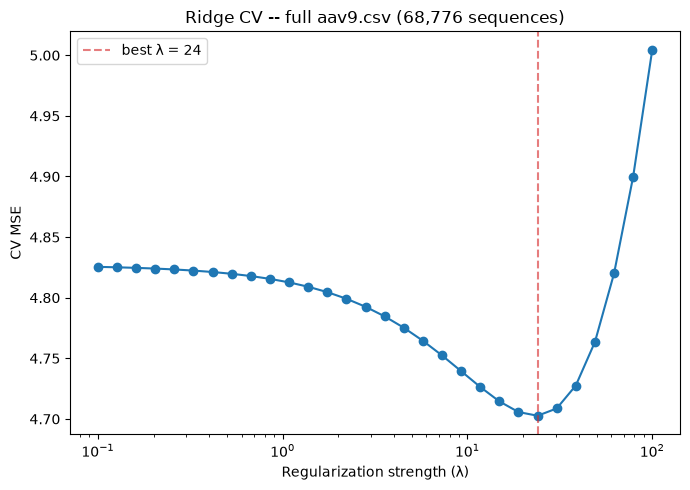

In [4]:
fig = plot_cv_curve(info_full["lambdas_grid"], info_full["cv_mse"],
                     title="Ridge CV -- full aav9.csv (68,776 sequences)")
plt.show()


### 3. Compare to the naive+shrinkage GT currently used by simulations

`load_F_viab_aav9_mlp`/`load_J_viab_aav9_mlp` (`lib/initialize_weights.py`) actually load the
naive group-means + empirical-Bayes-shrunk `J` (`F_viab_GT`/`J_naive_final` from
`AAV9_profile_model.ipynb` section 3c) -- **not** an MLP-derived matrix, despite the
function names. That's a stale docstring fixed in this same session (`lib/initialize_weights.py`);
the filenames (`aav9_F_viab_mlp.npy`) are left as-is to avoid a filename migration -- this is
the exact GT every `Protocol`/`ProtocolV2`/`ProtocolV3` in this project currently seeds
`F_viab`/`J_viab` with.

Pearson r(F_naive, F_potts)                     = +0.997
Pearson r(J_naive, J_potts), off-diagonal cells  = +0.839


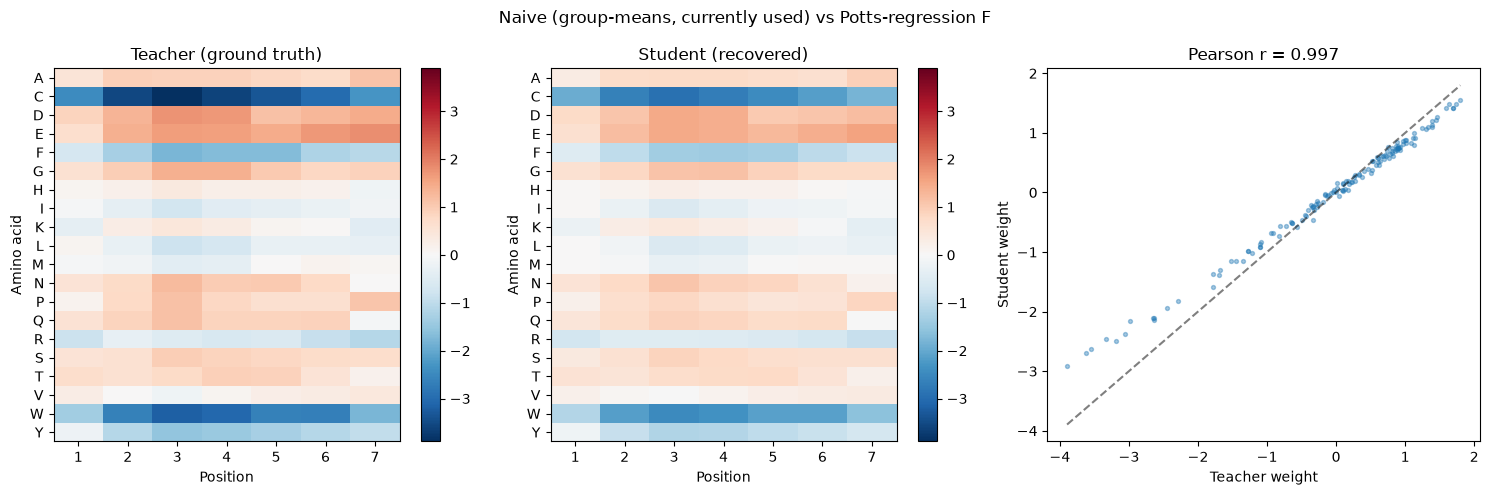

In [5]:
F_naive = np.array(load_F_viab_aav9_mlp())
J_naive = np.array(load_J_viab_aav9_mlp())

off_diag = ~np.eye(num_positions, dtype=bool)
r_F = pearson(F_naive.ravel(), np.array(F_potts).ravel())
r_J = pearson(J_naive[off_diag].ravel(), np.array(J_potts)[off_diag].ravel())
print(f"Pearson r(F_naive, F_potts)                     = {r_F:+.3f}")
print(f"Pearson r(J_naive, J_potts), off-diagonal cells  = {r_J:+.3f}")

fig = plot_teacher_vs_student(F_naive, np.array(F_potts),
                               title="Naive (group-means, currently used) vs Potts-regression F")
plt.show()


### 4. Held-out predictive check: does joint regression predict unseen real data better?

Absent for the naive GT today (it was only ever evaluated indirectly, via the brute-force /
model_mlp cross-checks in `AAV9_profile_model.ipynb`, never a direct held-out Pearson r on
real `target`). Same 50/50 split as `AAV9_profile_model.ipynb`
(`idx_train`/`idx_test`, `test_size=0.5, random_state=0`), so results are directly
comparable across notebooks. Fits Potts regression AND a plain naive baseline (group-means,
`min_support=5` hard cutoff -- the simplest form of "naive extraction", matching what the
naive per-cell functions from `AAV9_profile_model.ipynb` cells 11/24 compute *before* the 3c
attenuation is layered on) on `idx_train` only, scores both on `idx_test`'s real `target`.

In [6]:
# Reproduced verbatim from AAV9_profile_model.ipynb cells 11 and 24 (notebook-local helpers,
# not shared via lib/ -- same convention every AAV{2,5,9}_profile_model.ipynb already follows
# for its own notebook-local functions).

def F_groundtruth_viability(seq_matrix, target, num_amino_acids, num_positions):
    baseline = target.mean()
    F = np.full((num_amino_acids, num_positions), np.nan)
    counts = np.zeros((num_amino_acids, num_positions), dtype=int)
    for i in range(num_positions):
        for aa in range(num_amino_acids):
            mask = seq_matrix[:, i] == aa
            counts[aa, i] = mask.sum()
            if mask.any():
                F[aa, i] = target[mask].mean() - baseline
    return F, counts


def J_groundtruth_naive(seq_matrix, target, F, baseline, num_amino_acids, num_positions, min_support=5):
    L, A = num_positions, num_amino_acids
    J       = np.full((L, L, A, A), np.nan)
    J_raw   = np.full((L, L, A, A), np.nan)
    J_se    = np.full((L, L, A, A), np.inf)
    support = np.zeros((L, L, A, A), dtype=int)

    position_masks = [[seq_matrix[:, i] == a for a in range(A)] for i in range(L)]

    for i in range(L):
        for j in range(i + 1, L):
            for a in range(A):
                mask_a = position_masks[i][a]
                if not mask_a.any():
                    continue
                for b in range(A):
                    mask = mask_a & position_masks[j][b]
                    n = int(mask.sum())
                    support[i, j, a, b] = support[j, i, b, a] = n
                    if n >= 1:
                        vals_t = target[mask]
                        val = vals_t.mean() - baseline - F[a, i] - F[b, j]
                        J_raw[i, j, a, b] = J_raw[j, i, b, a] = val
                        if n >= 2:
                            se = vals_t.std(ddof=1) / np.sqrt(n)
                            J_se[i, j, a, b] = J_se[j, i, b, a] = se
                        if n >= min_support:
                            J[i, j, a, b] = J[j, i, b, a] = val
    return J, support, J_raw, J_se


def score_FJ(seq, F, J, baseline):
    L = seq.shape[1]
    F_part = F[seq, np.arange(L)].sum(axis=1).astype(np.float64)
    J_part = np.zeros(len(seq), dtype=np.float64)
    for i in range(L):
        for j in range(i + 1, L):
            J_part += J[i, j, seq[:, i], seq[:, j]]
    return F_part, J_part, baseline + F_part + J_part


In [7]:
idx_train, idx_test = train_test_split(np.arange(len(df)), test_size=0.5, random_state=0)
baseline_tr = float(target[idx_train].mean())

F_potts_tr, J_potts_tr, rank_tr, info_tr = R.fit_weights_potts_from_data(
    seq_matrix[idx_train], target[idx_train], seed=0, verbose=False,
)

F_naive_tr, _counts_tr = F_groundtruth_viability(
    seq_matrix[idx_train], target[idx_train], num_amino_acids, num_positions,
)
J_naive_tr, _support_tr, _J_raw_tr, _J_se_tr = J_groundtruth_naive(
    seq_matrix[idx_train], target[idx_train], F_naive_tr, baseline=baseline_tr,
    num_amino_acids=num_amino_acids, num_positions=num_positions, min_support=5,
)
J_naive_tr = np.nan_to_num(J_naive_tr, nan=0.0)

_, _, pred_potts_test = score_FJ(seq_matrix[idx_test], np.array(F_potts_tr), np.array(J_potts_tr), baseline_tr)
_, _, pred_naive_test = score_FJ(seq_matrix[idx_test], F_naive_tr, J_naive_tr, baseline_tr)

print("Held-out (idx_test, ~34,388 sequences) Pearson r -- real target vs prediction, "
      "both fit on idx_train only:")
print(f"  naive (group-means, min_support=5 hard cutoff) : {pearson(target[idx_test], pred_naive_test):+.4f}")
print(f"  Potts regression (ridge, CV lambda={info_tr['lam']:.3g})       : {pearson(target[idx_test], pred_potts_test):+.4f}")


Held-out (idx_test, ~34,388 sequences) Pearson r -- real target vs prediction, both fit on idx_train only:
  naive (group-means, min_support=5 hard cutoff) : +0.7821
  Potts regression (ridge, CV lambda=24)       : +0.8467


### 5. Credibility check: does the brute-force top-500 still show the F/J rescue pathology?

Same lightweight diagnostic as `AAV9_profile_model.ipynb` section 3c (cell 27): score
2,000,000 random sequences drawn uniformly from the full `20**7 ~= 1.28e9`-sequence space
with each method's FULL-data `F`/`J` (section 2/3 above, not the held-out split), and check
whether the top-500 lean on a large positive `J_part` to rescue a bad `F_part` -- the exact
pattern section 3c flags as not-credible.

In [8]:
rng_bf = np.random.default_rng(0)
N_BF, TOP_K_BF = 2_000_000, 500
seq_bf = rng_bf.integers(0, num_amino_acids, size=(N_BF, num_positions))
baseline_full = float(target.mean())

for name, F, J in [("naive (current GT, group-means + shrinkage)", F_naive, J_naive),
                    ("Potts regression (full data, ridge)", np.array(F_potts), np.array(J_potts))]:
    F_part, J_part, total = score_FJ(seq_bf, F, J, baseline_full)
    top_idx = np.argsort(-total)[:TOP_K_BF]
    print(f"{name}:")
    print(f"  top-{TOP_K_BF}      F_part mean={F_part[top_idx].mean():+.3f}  "
          f"J_part mean={J_part[top_idx].mean():+.3f}  "
          f"({(J_part[top_idx] > 0).mean() * 100:.1f}% positive J_part)")
    print(f"  random background  F_part mean={F_part.mean():+.3f}  "
          f"J_part mean={J_part.mean():+.3f}  "
          f"({(J_part > 0).mean() * 100:.1f}% positive J_part)")
    print()


naive (current GT, group-means + shrinkage):
  top-500      F_part mean=+6.996  J_part mean=+1.032  (95.4% positive J_part)
  random background  F_part mean=-0.296  J_part mean=-0.084  (46.5% positive J_part)

Potts regression (full data, ridge):
  top-500      F_part mean=+4.921  J_part mean=+4.357  (100.0% positive J_part)
  random background  F_part mean=+0.003  J_part mean=+0.003  (50.3% positive J_part)



### 5b. Sensitivity to lambda: GT score histograms across similar-MSE candidates

Section 2's CV picks ONE lambda (the CV-MSE minimum) to produce `F_potts`/`J_potts`. How much
does the resulting GT actually change if a nearby lambda -- with essentially the same held-out
predictive quality -- were chosen instead? Picks the `N_LAMBDA_CANDIDATES` lambdas from
`info_full["lambdas_grid"]` whose CV MSE is closest to the minimum (by MSE proximity, not grid
position), refits F/J at each on the full dataset, scores the real `aav9.csv` library with
each (`score_FJ`, section 4/5's helper), and overlays the resulting GT-score distributions --
if the GT were highly sensitive to this choice, that would be a red flag for how much to trust
any single lambda's fit; if the distributions basically coincide, the CV minimum's specific
value isn't doing much special work beyond "somewhere in this MSE-flat region".

In [9]:
N_LAMBDA_CANDIDATES = 50

lambdas_grid = np.asarray(info_full["lambdas_grid"])
cv_mse       = np.asarray(info_full["cv_mse"])
best_idx     = int(np.argmin(cv_mse))
best_mse     = cv_mse[best_idx]

candidate_idx = np.sort(np.argsort(np.abs(cv_mse - best_mse))[:N_LAMBDA_CANDIDATES])

X_full = R.build_potts_features(seq_matrix)

lambda_results = []
for idx in candidate_idx:
    lam = float(lambdas_grid[idx])
    is_best = bool(idx == best_idx)
    if is_best:
        F_lam, J_lam = F_potts, J_potts
    else:
        F_lam, J_lam = R.fit_weights_potts(X_full, target, T=1.0, lam=lam)
    _, _, gt_score_lam = score_FJ(seq_matrix, np.array(F_lam), np.array(J_lam), baseline_full)
    lambda_results.append(dict(lam=lam, cv_mse=float(cv_mse[idx]), is_best=is_best, gt_score=gt_score_lam))
    tag = "  <- CV minimum (= F_potts/J_potts)" if is_best else ""
    print(f"lambda={lam:8.3f}   CV MSE={cv_mse[idx]:.5f}{tag}")


lambda=   0.100   CV MSE=4.82546
lambda=   0.127   CV MSE=4.82510
lambda=   0.161   CV MSE=4.82464
lambda=   0.204   CV MSE=4.82406
lambda=   0.259   CV MSE=4.82332
lambda=   0.329   CV MSE=4.82239
lambda=   0.418   CV MSE=4.82122
lambda=   0.530   CV MSE=4.81974
lambda=   0.672   CV MSE=4.81789
lambda=   0.853   CV MSE=4.81557
lambda=   1.083   CV MSE=4.81267
lambda=   1.374   CV MSE=4.80907
lambda=   1.743   CV MSE=4.80462
lambda=   2.212   CV MSE=4.79918
lambda=   2.807   CV MSE=4.79256
lambda=   3.562   CV MSE=4.78463
lambda=   4.520   CV MSE=4.77528
lambda=   5.736   CV MSE=4.76450
lambda=   7.279   CV MSE=4.75243
lambda=   9.237   CV MSE=4.73947
lambda=  11.721   CV MSE=4.72640
lambda=  14.874   CV MSE=4.71450
lambda=  18.874   CV MSE=4.70571
lambda=  23.950   CV MSE=4.70265  <- CV minimum (= F_potts/J_potts)
lambda=  30.392   CV MSE=4.70867
lambda=  38.566   CV MSE=4.72760
lambda=  48.939   CV MSE=4.76348
lambda=  62.102   CV MSE=4.82000
lambda=  78.805   CV MSE=4.89994
lambda= 

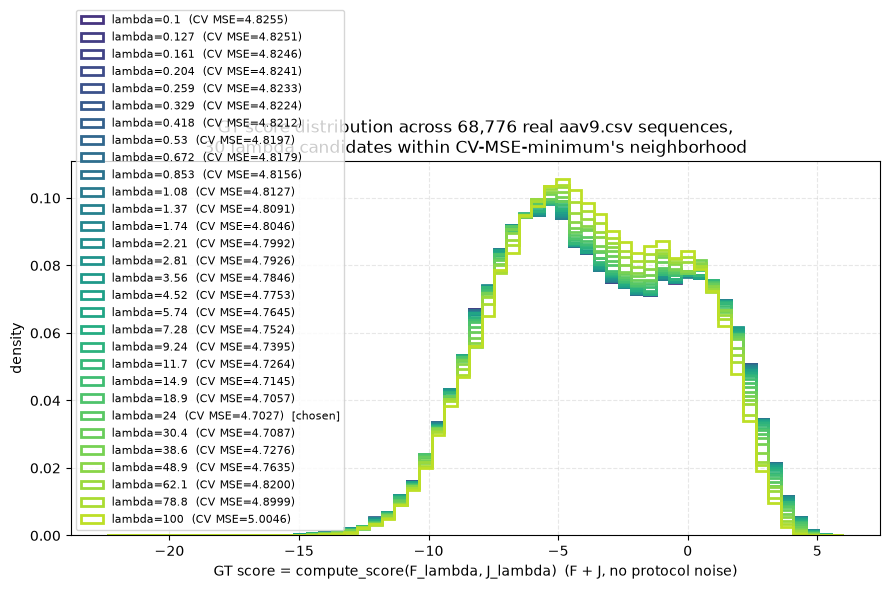

Pairwise similarity to the chosen (CV-minimum) lambda's GT score:
  lambda=   0.100   mean=-3.598  std=3.748  r(vs chosen)=0.9982
  lambda=   0.127   mean=-3.598  std=3.747  r(vs chosen)=0.9982
  lambda=   0.161   mean=-3.598  std=3.747  r(vs chosen)=0.9982
  lambda=   0.204   mean=-3.598  std=3.747  r(vs chosen)=0.9982
  lambda=   0.259   mean=-3.598  std=3.747  r(vs chosen)=0.9982
  lambda=   0.329   mean=-3.598  std=3.746  r(vs chosen)=0.9982
  lambda=   0.418   mean=-3.598  std=3.746  r(vs chosen)=0.9982
  lambda=   0.530   mean=-3.599  std=3.745  r(vs chosen)=0.9983
  lambda=   0.672   mean=-3.599  std=3.744  r(vs chosen)=0.9983
  lambda=   0.853   mean=-3.599  std=3.743  r(vs chosen)=0.9983
  lambda=   1.083   mean=-3.599  std=3.741  r(vs chosen)=0.9984
  lambda=   1.374   mean=-3.599  std=3.739  r(vs chosen)=0.9984
  lambda=   1.743   mean=-3.599  std=3.737  r(vs chosen)=0.9985
  lambda=   2.212   mean=-3.599  std=3.734  r(vs chosen)=0.9985
  lambda=   2.807   mean=-3.599  std=3

In [10]:
fig, ax = plt.subplots(figsize=(9, 5.5))
colors = plt.cm.viridis(np.linspace(0.15, 0.9, len(lambda_results)))
bins = np.linspace(
    min(r["gt_score"].min() for r in lambda_results),
    max(r["gt_score"].max() for r in lambda_results),
    60,
)
for r, color in zip(lambda_results, colors):
    label = f"lambda={r['lam']:.3g}  (CV MSE={r['cv_mse']:.4f})" + ("  [chosen]" if r["is_best"] else "")
    ax.hist(r["gt_score"], bins=bins, density=True, histtype="step", linewidth=2, color=color, label=label)
ax.set_xlabel("GT score = compute_score(F_lambda, J_lambda)  (F + J, no protocol noise)")
ax.set_ylabel("density")
ax.set_title(f"GT score distribution across {len(df):,} real aav9.csv sequences,\n"
             f"{len(lambda_results)} lambda candidates within CV-MSE-minimum's neighborhood")
ax.legend(fontsize=8)
ax.grid(True, linestyle="--", alpha=0.3)
fig.tight_layout()
plt.show()

ref = next(r for r in lambda_results if r["is_best"])["gt_score"]
print("Pairwise similarity to the chosen (CV-minimum) lambda's GT score:")
for r in lambda_results:
    tag = " (self)" if r["is_best"] else ""
    print(f"  lambda={r['lam']:8.3f}   mean={r['gt_score'].mean():+.3f}  std={r['gt_score'].std():.3f}  "
          f"r(vs chosen)={pearson(ref, r['gt_score']):.4f}{tag}")


### 6. Export `F_viab_potts` / `J_viab_potts`

Saved alongside (not overwriting) the existing naive-GT files -- both stay available so
`initialize_weights.py` callers can A/B test before this becomes the default GT for
simulations (which would also mean re-checking the `mu`/`T_viab`/`noise_viab`/`D` calibration
`AAV9_fitting_protocol.ipynb` did against the naive GT's scale).

In [11]:
F_VIAB_POTTS_PATH = os.path.join("..", "lib", "aav9_F_viab_potts.npy")
J_VIAB_POTTS_PATH = os.path.join("..", "lib", "aav9_J_viab_potts.npy")

np.save(F_VIAB_POTTS_PATH, np.array(F_potts, dtype=np.float32))
np.save(J_VIAB_POTTS_PATH, np.array(J_potts, dtype=np.float32))

print(f"Saved F_potts {F_potts.shape} to {os.path.abspath(F_VIAB_POTTS_PATH)}")
print(f"Saved J_potts {J_potts.shape} to {os.path.abspath(J_VIAB_POTTS_PATH)}")


Saved F_potts (20, 7) to /home/spark0735/MERLIN_YASSINE/Directed-Evolution-loop/Modelization_V2/lib/aav9_F_viab_potts.npy
Saved J_potts (7, 7, 20, 20) to /home/spark0735/MERLIN_YASSINE/Directed-Evolution-loop/Modelization_V2/lib/aav9_J_viab_potts.npy
